In [8]:
import torch
import torchvision.models as models
from PIL import Image
import matplotlib.pyplot as plt

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
weights = models.ResNet18_Weights.DEFAULT
preprocess = weights.transforms()
image = Image.open("dachshund.png").convert("RGB")
img_tensor = preprocess(image).unsqueeze(0)
img_tensor.shape

torch.Size([1, 3, 224, 224])

In [9]:
model.eval()
with torch.no_grad():
    output = model(img_tensor)
    prediction = output.argmax(dim=1)

prediction

tensor([236])

In [10]:
categories = weights.meta['categories']
predicted_name = categories[prediction.item()]
predicted_name

'Doberman'

In [11]:
top5 = torch.topk(output, 5, dim=1)
print(top5.indices)

tensor([[236, 165, 237, 234, 168]])


In [12]:
activations = {}
def hook_fn(module, input, output):
    activations['conv1'] = output

model.conv1.register_forward_hook(hook_fn)

model.eval()
with torch.no_grad():
    output = model(img_tensor)

print(activations['conv1'].shape)

torch.Size([1, 64, 112, 112])


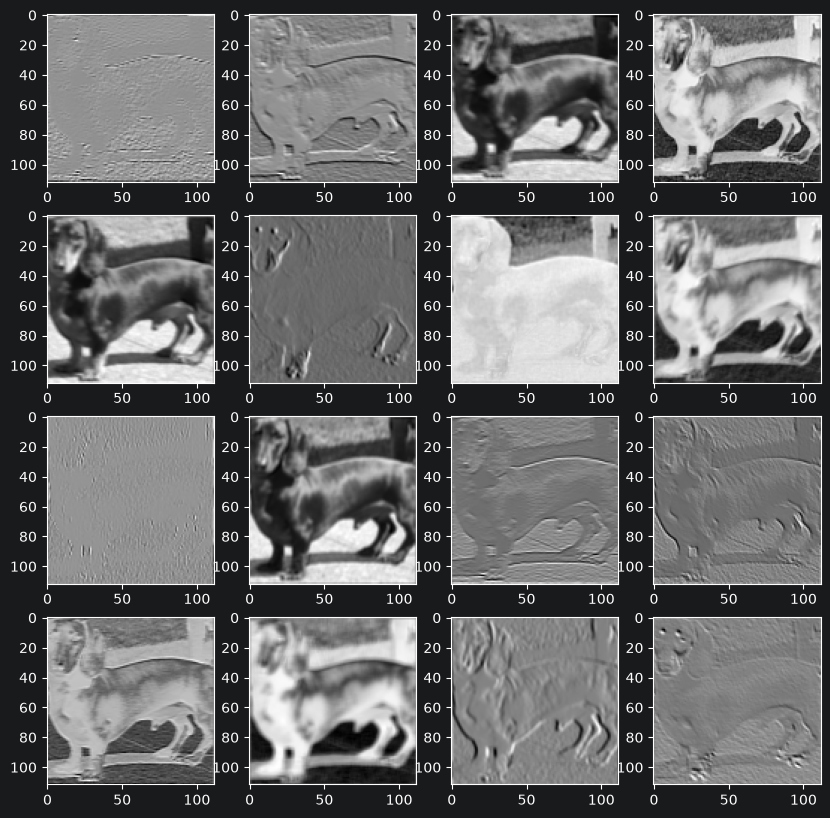

In [14]:
feature_maps = activations['conv1'].squeeze(0)
fig, axes = plt.subplots(4, 4, figsize=(10,10))
for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps[i].detach().numpy(), cmap='gray')
plt.show()